---
title: "Lecture 1 – Linear Regression"
subtitle: "ML – Missing Semester CUET"
format:
  html:
    code-fold: false
---

## What Is Supervised Learning?

Given a dataset of input-output pairs $\{(x^{(i)}, y^{(i)})\}_{i=1}^{m}$, learn a function $h$ that maps inputs to outputs.

- **Regression** → continuous output (price, temperature)
- **Classification** → discrete output (spam/ham, digit 0–9)

Today: **regression** — predicting a continuous value.

---

## The Linear Hypothesis

We model the relationship as a weighted sum of features:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n = \theta^T x$$

- $\theta_0$ — **bias** (intercept)
- $\theta_1 \ldots \theta_n$ — **weights** for each feature
- Goal: find the $\theta$ that best fits our data.

---

## Cost Function — Mean Squared Error

We measure "how wrong" our predictions are:

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)^2$$

- Convex → guaranteed single global minimum.
- The $\frac{1}{2}$ simplifies the gradient.

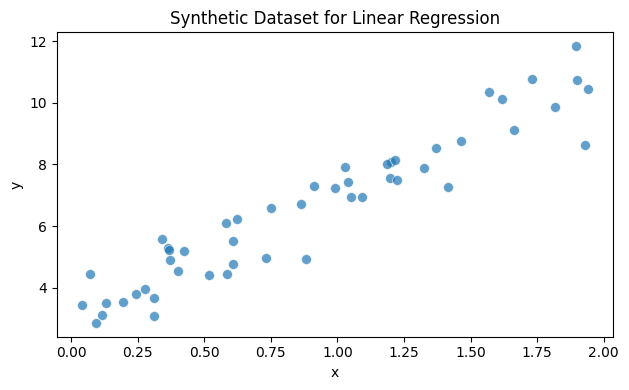

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
X = 2 * np.random.rand(50, 1)
y = 3 + 4 * X + np.random.randn(50, 1) * 0.8

plt.figure(figsize=(6.4, 4))
plt.scatter(X, y, alpha=0.7, edgecolors='white', linewidth=0.5, s=50)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Synthetic Dataset for Linear Regression')
plt.tight_layout()
plt.show()

---

## Gradient Descent

Iteratively update each parameter in the direction that reduces the cost:

$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j}J(\theta)$$

For MSE the partial derivative is:

$$\frac{\partial}{\partial \theta_j}J(\theta) = \frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}$$

**$\alpha$** is the **learning rate** — too large and we overshoot; too small and we crawl.

Learned parameters: theta_0 = 3.09, theta_1 = 3.90


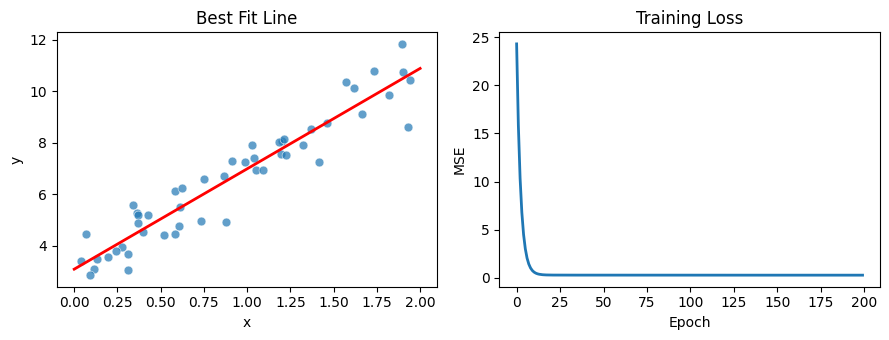

In [2]:
# Gradient descent implementation
X_b = np.c_[np.ones((50, 1)), X]  # add bias column
theta = np.zeros((2, 1))
alpha = 0.1
epochs = 200
m = len(X_b)
losses = []

for epoch in range(epochs):
    predictions = X_b @ theta
    error = predictions - y
    cost = (1 / (2 * m)) * np.sum(error ** 2)
    losses.append(cost)
    gradients = (1 / m) * X_b.T @ error
    theta -= alpha * gradients

print(f"Learned parameters: theta_0 = {theta[0,0]:.2f}, theta_1 = {theta[1,0]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# Fit plot
axes[0].scatter(X, y, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
x_line = np.linspace(0, 2, 100).reshape(-1, 1)
axes[0].plot(x_line, theta[0] + theta[1] * x_line, 'r-', linewidth=2)
axes[0].set_title('Best Fit Line'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Loss curve
axes[1].plot(losses, linewidth=2)
axes[1].set_title('Training Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')

plt.tight_layout(); plt.show()

---

## Evaluation Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | $\frac{1}{m}\sum|y_i - \hat{y}_i|$ | Average absolute error |
| **RMSE** | $\sqrt{\frac{1}{m}\sum(y_i - \hat{y}_i)^2}$ | Penalises large errors |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Fraction of variance explained |

---

## Key Takeaways

1. Linear regression finds the best-fit line by minimising MSE.
2. Gradient descent iteratively updates weights using the gradient.
3. The learning rate $\alpha$ controls the step size — tune it carefully.
4. Always evaluate with multiple metrics, not just loss.

**Next up →** Logistic Regression & Classification